In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
os.makedirs("../reports", exist_ok=True)
os.makedirs("../docs", exist_ok=True)

In [3]:
df = pd.read_csv("../reports/ranked_claims.csv")
df.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,policy_duration_days,claim_to_premium_ratio,injury_claim_ratio,property_claim_ratio,vehicle_claim_ratio,is_night_incident,multi_vehicle_flag,actual_fraud,risk_score
0,439,56,IN,250/500,500,1082.49,0,FEMALE,PhD,prof-specialty,chess,unmarried,36100,-55000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,SC,Columbus,12,3,NaN,2,3,NaN,56430,0,6270,50160,Honda,CRV,2014,2291,52.129812,0.0,0.111111,0.888889,0,1,0,0.998943
1,231,37,OH,250/500,500,920.81,0,FEMALE,High School,sales,chess,wife,0,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Hillsdale,14,1,YES,2,0,NaN,71190,0,7910,63280,Mercedes,C300,1997,8464,77.312366,0.0,0.111111,0.888889,0,0,1,0.998464
2,140,36,OH,500/1000,2000,979.26,0,FEMALE,JD,transport-moving,cross-fit,own-child,0,-67000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,NY,Riverwood,2,4,YES,0,2,YES,72800,14560,14560,43680,Honda,Accord,1998,5343,74.341850,0.2,0.200000,0.600000,1,1,0,0.995344
3,144,35,IL,100/300,500,1427.46,0,MALE,High School,machine-op-inspct,cross-fit,wife,0,0,Multi-vehicle Collision,Side Collision,Major Damage,Police,WV,Springfield,3,3,NaN,0,0,NaN,87900,17580,8790,61530,Dodge,Neon,1995,7823,61.577908,0.2,0.100000,0.700000,1,1,0,0.986976
4,381,55,OH,500/1000,500,1459.99,0,FEMALE,MD,other-service,chess,wife,35900,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbrook,8,1,YES,1,2,YES,60600,12120,6060,42420,Accura,TL,2011,8675,41.507134,0.2,0.100000,0.700000,0,0,0,0.983506


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nPreview:")
df.head()

Shape: (200, 42)

Columns:
['months_as_customer', 'age', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'policy_duration_days', 'claim_to_premium_ratio', 'injury_claim_ratio', 'property_claim_ratio', 'vehicle_claim_ratio', 'is_night_incident', 'multi_vehicle_flag', 'actual_fraud', 'risk_score']

Preview:


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,policy_duration_days,claim_to_premium_ratio,injury_claim_ratio,property_claim_ratio,vehicle_claim_ratio,is_night_incident,multi_vehicle_flag,actual_fraud,risk_score
0,439,56,IN,250/500,500,1082.49,0,FEMALE,PhD,prof-specialty,chess,unmarried,36100,-55000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,SC,Columbus,12,3,NaN,2,3,NaN,56430,0,6270,50160,Honda,CRV,2014,2291,52.129812,0.0,0.111111,0.888889,0,1,0,0.998943
1,231,37,OH,250/500,500,920.81,0,FEMALE,High School,sales,chess,wife,0,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Hillsdale,14,1,YES,2,0,NaN,71190,0,7910,63280,Mercedes,C300,1997,8464,77.312366,0.0,0.111111,0.888889,0,0,1,0.998464
2,140,36,OH,500/1000,2000,979.26,0,FEMALE,JD,transport-moving,cross-fit,own-child,0,-67000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,NY,Riverwood,2,4,YES,0,2,YES,72800,14560,14560,43680,Honda,Accord,1998,5343,74.341850,0.2,0.200000,0.600000,1,1,0,0.995344
3,144,35,IL,100/300,500,1427.46,0,MALE,High School,machine-op-inspct,cross-fit,wife,0,0,Multi-vehicle Collision,Side Collision,Major Damage,Police,WV,Springfield,3,3,NaN,0,0,NaN,87900,17580,8790,61530,Dodge,Neon,1995,7823,61.577908,0.2,0.100000,0.700000,1,1,0,0.986976
4,381,55,OH,500/1000,500,1459.99,0,FEMALE,MD,other-service,chess,wife,35900,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbrook,8,1,YES,1,2,YES,60600,12120,6060,42420,Accura,TL,2011,8675,41.507134,0.2,0.100000,0.700000,0,0,0,0.983506


In [5]:
if "risk_score" not in df.columns:
    raise ValueError("The file does not contain a 'risk_score' column. Check ranked_claims.csv")

df["risk_score"].describe()

count    200.000000
mean       0.322311
std        0.326378
min        0.001673
25%        0.062437
50%        0.171541
75%        0.602450
max        0.998943
Name: risk_score, dtype: float64

In [6]:
df["risk_score_100"] = (df["risk_score"] * 100).round(2)
df[["risk_score", "risk_score_100"]].head()

,risk_score,risk_score_100
0,0.998943,99.89
1,0.998464,99.85
2,0.995344,99.53
3,0.986976,98.70
4,0.983506,98.35


In [7]:
def assign_risk_band(score):
    if score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

df["risk_band"] = df["risk_score_100"].apply(assign_risk_band)
df["risk_band"].value_counts()

risk_band
Low       137
High       41
Medium     22
Name: count, dtype: int64

In [8]:
df = df.sort_values(by="risk_score", ascending=False).reset_index(drop=True)
df["priority_rank"] = df.index + 1
df.head(10)

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,policy_duration_days,claim_to_premium_ratio,injury_claim_ratio,property_claim_ratio,vehicle_claim_ratio,is_night_incident,multi_vehicle_flag,actual_fraud,risk_score,risk_score_100,risk_band,priority_rank
0,439,56,IN,250/500,500,1082.49,0,FEMALE,PhD,prof-specialty,chess,unmarried,36100,-55000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,SC,Columbus,12,3,NaN,2,3,NaN,56430,0,6270,50160,Honda,CRV,2014,2291,52.129812,0.000000,0.111111,0.888889,0,1,0,0.998943,99.89,High,1
1,231,37,OH,250/500,500,920.81,0,FEMALE,High School,sales,chess,wife,0,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Hillsdale,14,1,YES,2,0,NaN,71190,0,7910,63280,Mercedes,C300,1997,8464,77.312366,0.000000,0.111111,0.888889,0,0,1,0.998464,99.85,High,2
2,140,36,OH,500/1000,2000,979.26,0,FEMALE,JD,transport-moving,cross-fit,own-child,0,-67000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,NY,Riverwood,2,4,YES,0,2,YES,72800,14560,14560,43680,Honda,Accord,1998,5343,74.341850,0.200000,0.200000,0.600000,1,1,0,0.995344,99.53,High,3
3,144,35,IL,100/300,500,1427.46,0,MALE,High School,machine-op-inspct,cross-fit,wife,0,0,Multi-vehicle Collision,Side Collision,Major Damage,Police,WV,Springfield,3,3,NaN,0,0,NaN,87900,17580,8790,61530,Dodge,Neon,1995,7823,61.577908,0.200000,0.100000,0.700000,1,1,0,0.986976,98.70,High,4
4,381,55,OH,500/1000,500,1459.99,0,FEMALE,MD,other-service,chess,wife,35900,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbrook,8,1,YES,1,2,YES,60600,12120,6060,42420,Accura,TL,2011,8675,41.507134,0.200000,0.100000,0.700000,0,0,0,0.983506,98.35,High,5
5,463,59,IL,250/500,1000,979.73,0,FEMALE,JD,exec-managerial,yachting,not-in-family,51700,0,Multi-vehicle Collision,Front Collision,Major Damage,Other,SC,Columbus,14,2,NaN,1,2,NO,72400,7240,14480,50680,Chevrolet,Tahoe,1999,7498,73.897911,0.100000,0.200000,0.700000,0,1,1,0.975973,97.60,High,6
6,322,44,IL,100/300,1000,1156.19,0,FEMALE,College,machine-op-inspct,cross-fit,husband,49900,-62700,Multi-vehicle Collision,Side Collision,Major Damage,Fire,NY,Northbrook,20,3,YES,0,3,NaN,49400,9880,4940,34580,Jeep,Wrangler,2010,3710,42.726541,0.200000,0.100000,0.700000,0,1,0,0.970085,97.01,High,7
7,111,27,OH,250/500,500,1459.97,5000000,MALE,MD,sales,yachting,other-relative,0,0,Multi-vehicle Collision,Side Collision,Major Damage,Police,SC,Northbend,2,3,NO,1,2,NO,80850,7350,14700,58800,Ford,F150,2011,4541,55.377850,0.090909,0.181818,0.727273,1,1,1,0.967961,96.80,High,8
8,219,43,IN,100/300,1000,1114.29,0,FEMALE,High School,transport-moving,polo,other-relative,51300,0,Single Vehicle Collision,Side Collision,Major Damage,Ambulance,VA,Northbrook,1,1,NaN,2,2,YES,66660,6060,6060,54540,Toyota,Highlander,2006,4585,59.822847,0.090909,0.090909,0.818182,1,0,0,0.963535,96.35,High,9
9,138,30,OH,500/1000,500,1093.07,4000000,FEMALE,PhD,other-service,reading,wife,27700,-72400,Single Vehicle Collision,Front Collision,Major Damage,Other,VA,Hillsdale,0,1,NaN,2,2,NO,83160,6930,13860,62370,Volkswagen,Jetta,2011,4745,76.079300,0.083333,0.166667,0.750000,1,0,0,0.962929,96.29,High,10


In [9]:
def investigation_action(risk_band):
    if risk_band == "High":
        return "Immediate Review"
    elif risk_band == "Medium":
        return "Secondary Review"
    else:
        return "Routine Processing"

df["recommended_action"] = df["risk_band"].apply(investigation_action)
df[["risk_band", "recommended_action"]].drop_duplicates()

,risk_band,recommended_action
0,High,Immediate Review
41,Medium,Secondary Review
63,Low,Routine Processing


In [10]:
df["risk_percentile_group"] = pd.qcut(
    df["risk_score"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)
df["risk_percentile_group"].value_counts()

risk_percentile_group
Very Low     40
Low          40
Medium       40
High         40
Very High    40
Name: count, dtype: int64

In [11]:
priority_cols = [
    "priority_rank",
    "risk_score",
    "risk_score_100",
    "risk_band",
    "risk_percentile_group",
    "recommended_action",
    "actual_fraud"
]

existing_priority_cols = [col for col in priority_cols if col in df.columns]
remaining_cols = [col for col in df.columns if col not in existing_priority_cols]

df = df[existing_priority_cols + remaining_cols]
df.head()

,priority_rank,risk_score,risk_score_100,risk_band,risk_percentile_group,recommended_action,actual_fraud,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,policy_duration_days,claim_to_premium_ratio,injury_claim_ratio,property_claim_ratio,vehicle_claim_ratio,is_night_incident,multi_vehicle_flag
0,1,0.998943,99.89,High,Very High,Immediate Review,0,439,56,IN,250/500,500,1082.49,0,FEMALE,PhD,prof-specialty,chess,unmarried,36100,-55000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,SC,Columbus,12,3,NaN,2,3,NaN,56430,0,6270,50160,Honda,CRV,2014,2291,52.129812,0.0,0.111111,0.888889,0,1
1,2,0.998464,99.85,High,Very High,Immediate Review,1,231,37,OH,250/500,500,920.81,0,FEMALE,High School,sales,chess,wife,0,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Hillsdale,14,1,YES,2,0,NaN,71190,0,7910,63280,Mercedes,C300,1997,8464,77.312366,0.0,0.111111,0.888889,0,0
2,3,0.995344,99.53,High,Very High,Immediate Review,0,140,36,OH,500/1000,2000,979.26,0,FEMALE,JD,transport-moving,cross-fit,own-child,0,-67000,Multi-vehicle Collision,Front Collision,Major Damage,Fire,NY,Riverwood,2,4,YES,0,2,YES,72800,14560,14560,43680,Honda,Accord,1998,5343,74.341850,0.2,0.200000,0.600000,1,1
3,4,0.986976,98.70,High,Very High,Immediate Review,0,144,35,IL,100/300,500,1427.46,0,MALE,High School,machine-op-inspct,cross-fit,wife,0,0,Multi-vehicle Collision,Side Collision,Major Damage,Police,WV,Springfield,3,3,NaN,0,0,NaN,87900,17580,8790,61530,Dodge,Neon,1995,7823,61.577908,0.2,0.100000,0.700000,1,1
4,5,0.983506,98.35,High,Very High,Immediate Review,0,381,55,OH,500/1000,500,1459.99,0,FEMALE,MD,other-service,chess,wife,35900,0,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbrook,8,1,YES,1,2,YES,60600,12120,6060,42420,Accura,TL,2011,8675,41.507134,0.2,0.100000,0.700000,0,0


In [12]:
summary = {
    "total_claims": len(df),
    "high_risk_claims": (df["risk_band"] == "High").sum(),
    "medium_risk_claims": (df["risk_band"] == "Medium").sum(),
    "low_risk_claims": (df["risk_band"] == "Low").sum()
}

summary

{'total_claims': 200,
 'high_risk_claims': np.int64(41),
 'medium_risk_claims': np.int64(22),
 'low_risk_claims': np.int64(137)}

In [13]:
if "actual_fraud" in df.columns:
    risk_band_fraud_summary = df.groupby("risk_band")["actual_fraud"].agg(["count", "sum", "mean"]).reset_index()
    risk_band_fraud_summary = risk_band_fraud_summary.rename(columns={
        "count": "claims_count",
        "sum": "fraud_cases",
        "mean": "fraud_rate"
    })
    risk_band_fraud_summary["fraud_rate"] = risk_band_fraud_summary["fraud_rate"].round(4)
    risk_band_fraud_summary
else:
    print("actual_fraud column not found.")

In [14]:
df.to_csv("../reports/final_prioritised_claims.csv", index=False)
print("Saved to ../reports/final_prioritised_claims.csv")

Saved to ../reports/final_prioritised_claims.csv


In [15]:
if "actual_fraud" in df.columns:
    risk_band_fraud_summary.to_csv("../reports/risk_band_summary.csv", index=False)
    print("Saved to ../reports/risk_band_summary.csv")

Saved to ../reports/risk_band_summary.csv


In [16]:
summary_df = pd.DataFrame([summary])
summary_df.to_csv("../reports/dashboard_summary.csv", index=False)
print("Saved to ../reports/dashboard_summary.csv")
summary_df

Saved to ../reports/dashboard_summary.csv


,total_claims,high_risk_claims,medium_risk_claims,low_risk_claims
0,200,41,22,137


In [17]:
# Create Top 20 priority claims
top_20_claims = df.head(20)

# Save it
top_20_claims.to_csv("../reports/top_20_priority_claims.csv", index=False)

print("Saved to ../reports/top_20_priority_claims.csv")


Saved to ../reports/top_20_priority_claims.csv


In [18]:
import matplotlib.pyplot as plt
import joblib

best_pipeline = joblib.load("../models/fraud_model_pipeline.pkl")


model = best_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(15)

    importance_df.plot(kind="barh", x="feature", y="importance", figsize=(8,6))
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importances")
    plt.show()

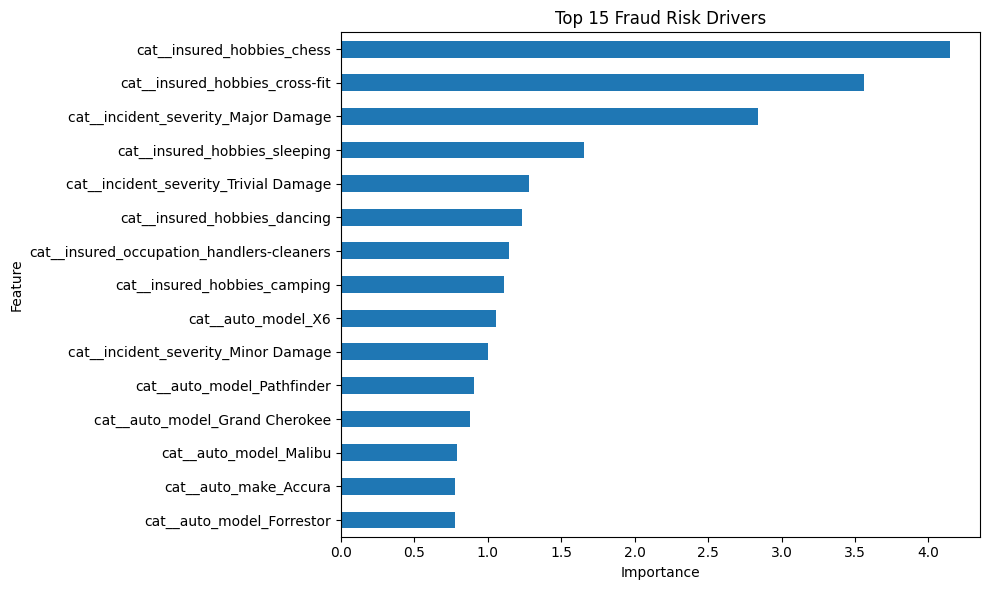

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

model = best_pipeline.named_steps["model"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
elif hasattr(model, "coef_"):
    importance_values = abs(model.coef_[0])
else:
    raise ValueError("This model does not support feature importance or coefficients.")

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
}).sort_values(by="importance", ascending=False).head(15)

importance_df.plot(kind="barh", x="feature", y="importance", figsize=(10, 6), legend=False)
plt.gca().invert_yaxis()
plt.title("Top 15 Fraud Risk Drivers")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../reports/figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
import shap
import joblib

# Load model
best_pipeline = joblib.load("../models/fraud_model_pipeline.pkl")

model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Transform data
X_transformed = preprocessor.transform(X_test)

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(model, X_transformed)

shap_values = explainer(X_transformed)

shap.plots.bar(shap_values)

NameError: name 'X_test' is not defined

In [ ]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("../reports/figures", exist_ok=True)

# Use the best trained tree-based model
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary_plot.png", bbox_inches="tight")
plt.show()

# SHAP Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_feature_importance.png", bbox_inches="tight")
plt.show()